In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### EDA – Diagnóstico Exploratorio

In [51]:
# Cargar el archivo
df = pd.read_excel('BD_Tlaxcala_RETO.xlsx')

# Primer paso del EDA: Ver qué tenemos
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82801 entries, 0 to 82800
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   lat          82801 non-null  float64
 1   long         82801 non-null  float64
 2   nombre_act   82801 non-null  object 
 3   fuente       82801 non-null  object 
 4   id           82801 non-null  int64  
 5   nom_estab    82800 non-null  object 
 6   per_ocu      82801 non-null  object 
 7   tipo_vial    82438 non-null  object 
 8   nom_vial     82801 non-null  object 
 9   tipo_asent   82587 non-null  object 
 10  cod_postal   81521 non-null  float64
 11  entidad      82801 non-null  object 
 12  municipio    82801 non-null  object 
 13  localidad    82801 non-null  object 
 14  tipoUniEco   82801 non-null  object 
 15  fecha_alta   82801 non-null  object 
 16  Tam_negocio  82801 non-null  object 
dtypes: float64(3), int64(1), object(13)
memory usage: 10.7+ MB
None
         lat       long 

##### Manejando los N/A

In [52]:
# Conteo inicial de NA
print("NA iniciales en CP:", df['cod_postal'].isna().sum())

# Tabla de referencia usando moda por municipio-localidad
referencia_cp = (
    df.dropna(subset=['cod_postal'])
      .groupby(['municipio', 'localidad'])['cod_postal']
      .agg(lambda x: x.value_counts().index[0])
      .reset_index()
)

referencia_cp.columns = ['municipio', 'localidad', 'cp_sugerido']

# Merge
df = df.merge(referencia_cp, on=['municipio','localidad'], how='left')

# Imputación
df['cod_postal'] = df['cod_postal'].fillna(df['cp_sugerido'])

df.drop(columns=['cp_sugerido'], inplace=True)

print("NA después de imputación:", df['cod_postal'].isna().sum())

NA iniciales en CP: 1280
NA después de imputación: 2


##### Manejo de Codigo postal

In [53]:
#  Convertir a entero (para quitar el .0) y luego a texto (string)
# Usamos 'Int64' (con I mayúscula) porque permite manejar los 2 NAs que quedaron
df['cod_postal'] = df['cod_postal'].astype('Int64').astype(str)

# Verificamos
print(df['cod_postal'].unique()[:10])

['90620' '90600' '90606' '90407' '90300' '90401' '90550' '90235' '90200'
 '90800']


In [54]:
print("NA iniciales en CP:", df['cod_postal'].isna().sum())

NA iniciales en CP: 0


##### manejo de ecoding


In [55]:
# Definimos un diccionario con los errores más comunes 
reemplazos = {
    '√≠': 'í',
    '√≥': 'ó',
    '√°': 'á',
    '√©': 'é',
    '√∫': 'ú',
    '√±': 'ñ',
    '√±': 'Ñ',
    '√î': 'Ó',
    '√Å': 'Á'
}
# Aplicamos los reemplazos en las columnas de texto
for error, correccion in reemplazos.items():
    df['nombre_act'] = df['nombre_act'].str.replace(error, correccion, regex=False)
    df['municipio'] = df['municipio'].str.replace(error, correccion, regex=False)
    df['localidad'] = df['localidad'].str.replace(error, correccion, regex=False)

# Verificamos los primeros resultados
print(df['nombre_act'].head())

0          Salones y clínicas de belleza y peluquerías
1    Centros de acondicionamiento físico del sector...
2    Consultorios de medicina general del sector pr...
3    Centros de acondicionamiento físico del sector...
4         Lavado y lubricado de automóviles y camiones
Name: nombre_act, dtype: object


Resumen de variables categóricas clave:
       Tam_negocio tipoUniEco
count        82801      82801
unique           4          2
top          Chico       Fijo
freq         81826      81774


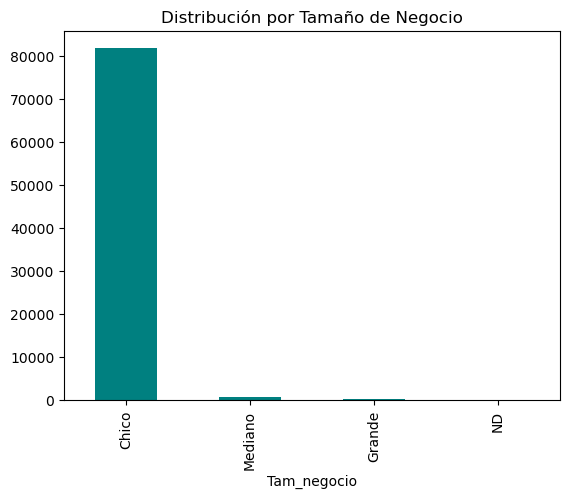

In [16]:
# Resumen estadístico de las variables numéricas y categóricas

print("Resumen de variables categóricas clave:")
print(df[['Tam_negocio', 'tipoUniEco']].describe())

# Ver la distribución de los negocios por tamaño
df['Tam_negocio'].value_counts().plot(kind='bar', title='Distribución por Tamaño de Negocio', color='teal')
plt.show()

Top 5 Municipios con mayor actividad comercial:
municipio
Tlaxcala               8262
Apizaco                8188
Chiautempan            6954
Huamantla              5717
San Pablo del Monte    5501
Name: count, dtype: int64


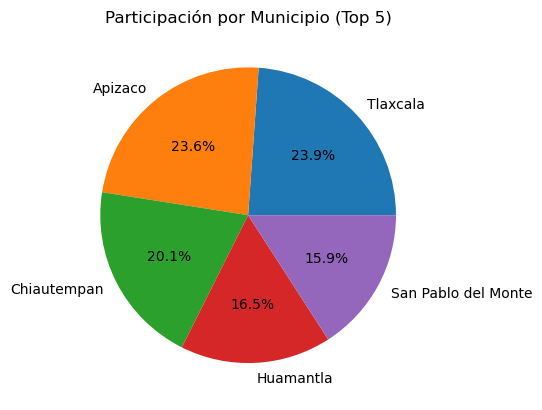

In [58]:
# Municipios con más negocios
top_municipios = df['municipio'].value_counts().head(5)
print("Top 5 Municipios con mayor actividad comercial:")
print(top_municipios)

# Gráfico rápido de municipios
top_municipios.plot(kind='pie', autopct='%1.1f%%', title='Participación por Municipio (Top 5)')
plt.ylabel('')
plt.show()

### ¿En qué códigos postales hay mayor densidad comercial?

Top 5 Códigos Postales con Mayor Densidad Comercial en Tlaxcala:
  Código Postal  Cantidad de Negocios
0         90300                  4243
1         90800                  3050
2         90500                  3036
3         90740                  2948
4         90000                  2304


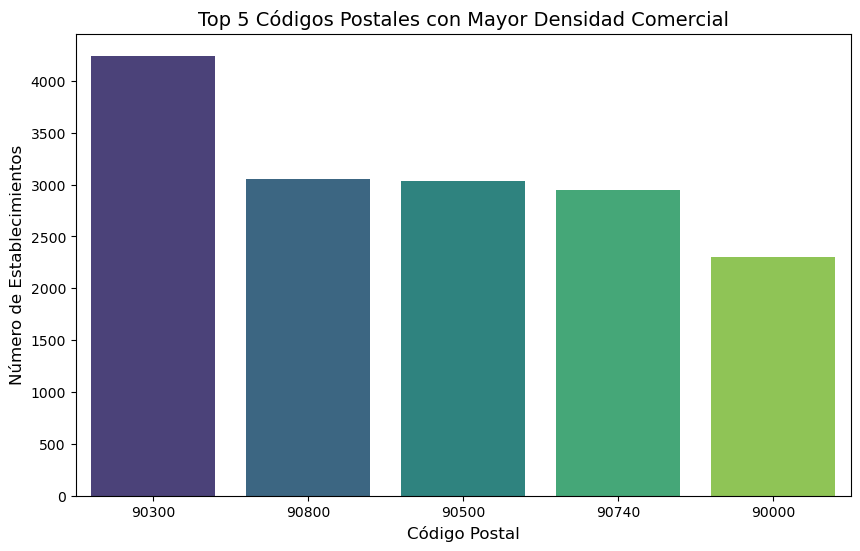

In [59]:

# value_counts() cuenta cuántas veces aparece cada código postal
densidad_por_cp = df['cod_postal'].value_counts().reset_index()

# Renombramos las columnas para que sean más claras y entendibles
densidad_por_cp.columns = ['Código Postal', 'Cantidad de Negocios']

# los primeros 5 son los de mayor densidad comercial
top_5_cp = densidad_por_cp.head(5)

# Mostramos el resultado en consola
print("Top 5 Códigos Postales con Mayor Densidad Comercial en Tlaxcala:")
print(top_5_cp)

# Definimos tamaño de la figura
plt.figure(figsize=(10, 6))

# Creamos gráfico de barras:
sns.barplot(
    data=top_5_cp,
    x='Código Postal',
    y='Cantidad de Negocios',
    hue='Código Postal',
    palette='viridis',
    legend=False
)

# Título y etiquetas del gráfico
plt.title('Top 5 Códigos Postales con Mayor Densidad Comercial', fontsize=14)
plt.xlabel('Código Postal', fontsize=12)
plt.ylabel('Número de Establecimientos', fontsize=12)

# Mostramos el gráfico
plt.show()

### ¿Qué actividades predominan en el CP 90300?

Top 5 Actividades en el CP 90300:
nombre_act
Comercio al por menor de ropa, excepto de bebé y lencería                    236
Salones y clínicas de belleza y peluquerías                                  171
Comercio al por menor en tiendas de abarrotes, ultramarinos y misceláneas    144
Comercio al por menor de frutas y verduras frescas                           123
Restaurantes con servicio de preparación de tacos y tortas                   105
Name: count, dtype: int64


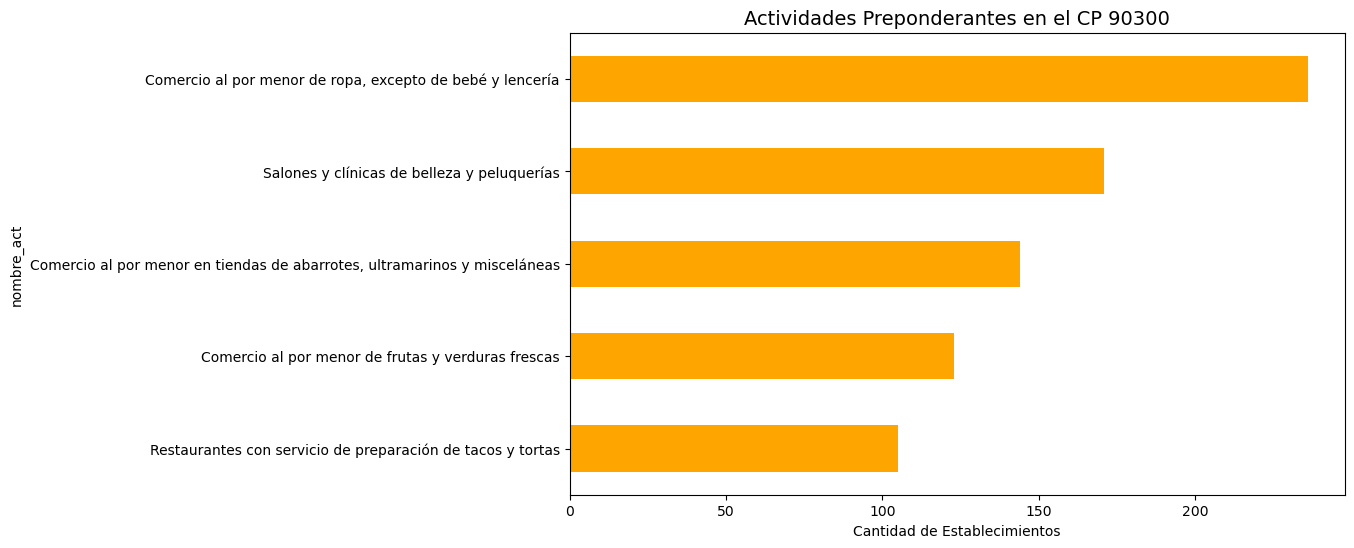

In [60]:
# Analizar el CP con más densidad (90300)
cp_mayor_densidad = "90300"
top_actividades_90300 = df[df['cod_postal'] == cp_mayor_densidad]['nombre_act'].value_counts().head(5)

print(f"Top 5 Actividades en el CP {cp_mayor_densidad}:")
print(top_actividades_90300)

# Gráfico de apoyo para el Punto 3
plt.figure(figsize=(10,6))
top_actividades_90300.plot(kind='barh', color='orange')
plt.title(f'Actividades Preponderantes en el CP {cp_mayor_densidad}', fontsize=14)
plt.xlabel('Cantidad de Establecimientos')
plt.gca().invert_yaxis() # Para que la más alta salga arriba
plt.show()

### ¿Existe diferencia significativa en tamaño?

In [61]:
from scipy.stats import chi2_contingency

# Tomamos los 5 CP con mayor densidad
top_cp = top_5_cp['Código Postal']

df_top = df[df['cod_postal'].isin(top_cp)]

# Creamos tabla de contingencia
tabla = pd.crosstab(df_top['cod_postal'], df_top['Tam_negocio'])

print("Tabla de Contingencia:")
print(tabla)

# Aplicamos prueba Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla)

print("\nResultados prueba Chi-cuadrado")
print("Chi2:", chi2)
print("p-value:", p)
print("Grados de libertad:", dof)

Tabla de Contingencia:
Tam_negocio  Chico  Grande  Mediano  ND
cod_postal                             
90000         2239      24       41   0
90300         4192      13       36   2
90500         2993      17       26   0
90740         2931       4       13   0
90800         3014       7       29   0

Resultados prueba Chi-cuadrado
Chi2: 64.42931233222927
p-value: 3.475283740703131e-09
Grados de libertad: 12


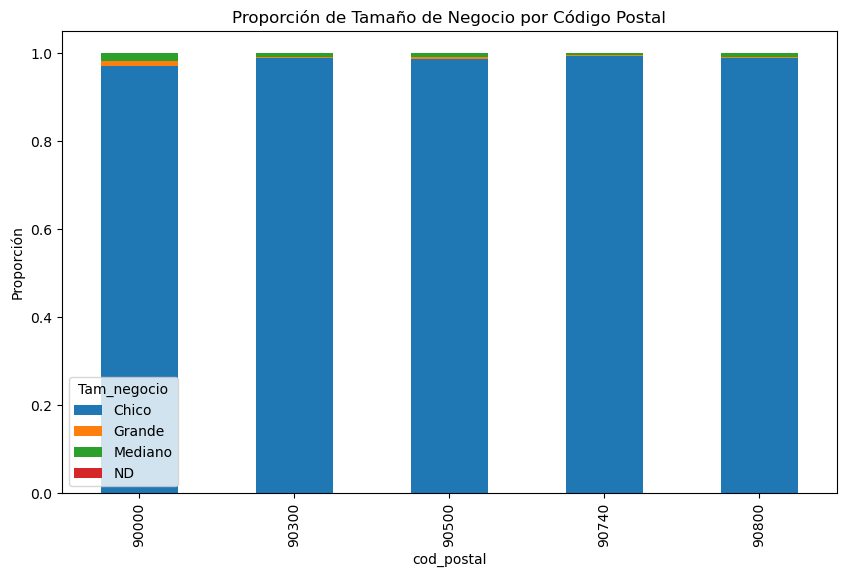

In [15]:
tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)

tabla_prop.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Proporción de Tamaño de Negocio por Código Postal")
plt.ylabel("Proporción")
plt.show()

### Organización estratégica por código postal

In [27]:

# se crea un resumen estadístico por Código Postal

# Agrupamos el DataFrame por 'cod_postal'
resumen_cp = df.groupby('cod_postal').agg(
    
    # Cuenta cuántos registros (ids) hay en cada grupo
    total_negocios=('id', 'count'),
    
    #Cantidad de negocios chico
    negocios_chicos=('Tam_negocio', lambda x: (x == 'Chico').sum()),
    
    #  Cantidad de negocios medianos
    negocios_medianos=('Tam_negocio', lambda x: (x == 'Mediano').sum()),
    
    #Cantidad de negocios grandes
    negocios_grandes=('Tam_negocio', lambda x: (x == 'Grande').sum()),
    
    # Número de actividades económicas distintas
    actividades_distintas=('nombre_act', 'nunique'),
    
    #  Latitud promedio
    lat_promedio=('lat', 'mean'),
    
    # Longitud promedio
    long_promedio=('long', 'mean')

# Después del groupby, el código postal queda como índice.
).reset_index()

# Mostrar las primeras filas del resumen generado
print(resumen_cp.head())

  cod_postal  total_negocios  negocios_chicos  negocios_medianos  \
0      66260               1                0                  0   
1      72140               1                1                  0   
2      72160               3                3                  0   
3      72170               1                1                  0   
4      72260               1                1                  0   

   negocios_grandes  actividades_distintas  lat_promedio  long_promedio  
0                 1                      1     19.489306     -98.059585  
1                 0                      1     19.597650     -98.219987  
2                 0                      1     19.561023     -98.226089  
3                 0                      1     19.511029     -98.246693  
4                 0                      1     19.419470     -98.157780  


### Modelo de Segmentación Geoespacial (K-Means)


In [28]:
resumen_cp.columns

Index(['cod_postal', 'total_negocios', 'negocios_chicos', 'negocios_medianos',
       'negocios_grandes', 'actividades_distintas', 'lat_promedio',
       'long_promedio'],
      dtype='object')

In [29]:
#Crear proporciones estructurales
resumen_cp['prop_chicos'] = resumen_cp['negocios_chicos'] / resumen_cp['total_negocios']
resumen_cp['prop_medianos'] = resumen_cp['negocios_medianos'] / resumen_cp['total_negocios']
resumen_cp['prop_grandes'] = resumen_cp['negocios_grandes'] / resumen_cp['total_negocios']

In [30]:
# Seleccionar variables para el clustering
X = resumen_cp[[
    'total_negocios',
    'actividades_distintas',
    'prop_chicos',
    'prop_medianos',
    'prop_grandes',
    'lat_promedio',
    'long_promedio'
]]

In [31]:
# Escalar variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
# Aplicar K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
resumen_cp['cluster'] = kmeans.fit_predict(X_scaled)

In [33]:
resumen_cp.groupby('cluster').mean(numeric_only=True)

,total_negocios,negocios_chicos,negocios_medianos,negocios_grandes,actividades_distintas,lat_promedio,long_promedio,prop_chicos,prop_medianos,prop_grandes
cluster,,,,,,,,,,
0,1288.222222,1272.444444,10.972222,4.750000,194.777778,19.312086,-98.192240,0.987646,0.008495,0.003846
1,136.522822,135.124481,1.087137,0.307054,45.647303,19.323924,-98.153270,0.990353,0.007042,0.002595
2,70.240000,69.020000,0.860000,0.360000,23.740000,19.525289,-98.309255,0.834374,0.158398,0.007227
3,1.833333,0.333333,0.166667,1.333333,1.833333,19.379108,-98.162035,0.166667,0.083333,0.750000


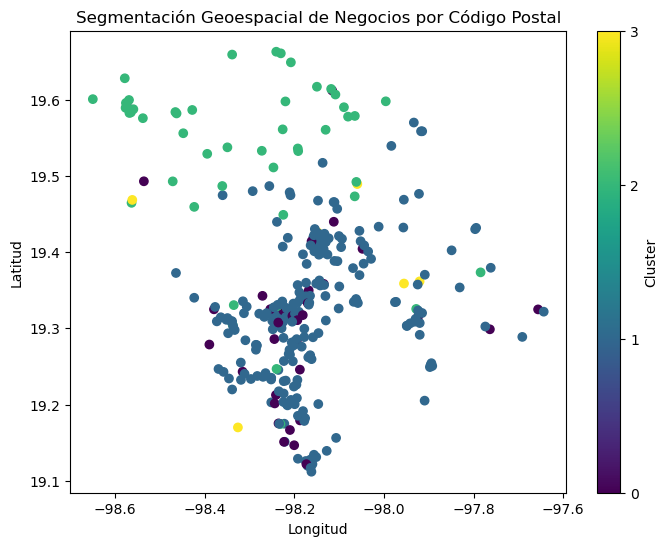

In [62]:
# vizualizamos los cluster
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    resumen_cp['long_promedio'],
    resumen_cp['lat_promedio'],
    c=resumen_cp['cluster'],
    cmap='viridis'
)

plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Segmentación Geoespacial de Negocios por Código Postal')

#  Crear barra de color
cbar = plt.colorbar(scatter)

#  Forzar que solo muestre 0,1,2,3 (sin decimales)
clusters_unicos = np.sort(resumen_cp['cluster'].unique())
cbar.set_ticks(clusters_unicos)
cbar.set_ticklabels(clusters_unicos)

cbar.set_label('Cluster')

plt.show()

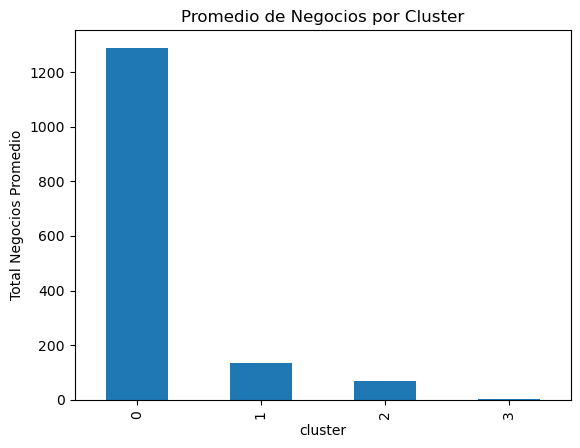

In [31]:
resumen_cp.groupby('cluster')['total_negocios'].mean().plot(kind='bar')
plt.title('Promedio de Negocios por Cluster')
plt.ylabel('Total Negocios Promedio')
plt.show()

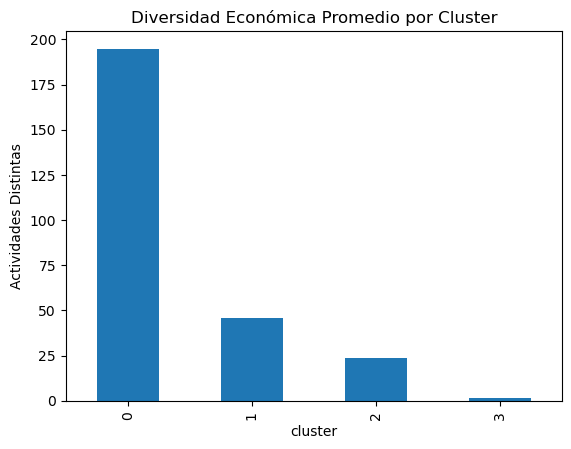

In [32]:
resumen_cp.groupby('cluster')['actividades_distintas'].mean().plot(kind='bar')
plt.title('Diversidad Económica Promedio por Cluster')
plt.ylabel('Actividades Distintas')
plt.show()

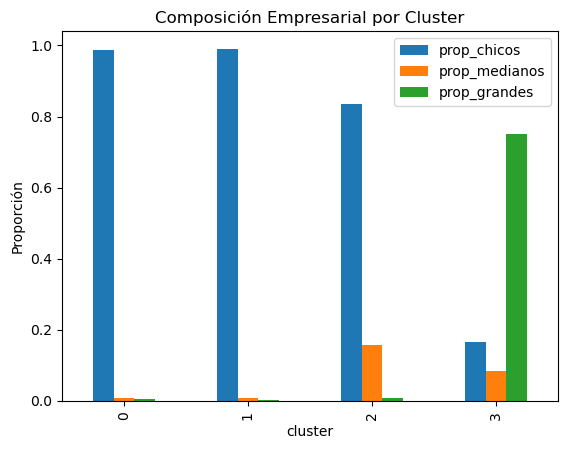

In [33]:
resumen_cp.groupby('cluster')[['prop_chicos','prop_medianos','prop_grandes']].mean().plot(kind='bar')
plt.title('Composición Empresarial por Cluster')
plt.ylabel('Proporción')
plt.show()

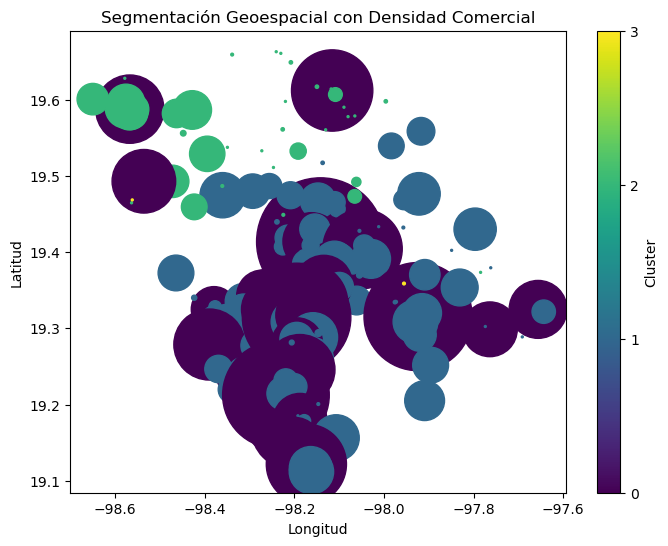

In [40]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    resumen_cp['long_promedio'],
    resumen_cp['lat_promedio'],
    s=resumen_cp['total_negocios']*2,
    c=resumen_cp['cluster'],
    cmap='viridis'
)

plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Segmentación Geoespacial con Densidad Comercial')

#  Agregar barra de color (leyenda de clusters)
cbar = plt.colorbar(scatter)

# Mostrar solo valores enteros de cluster
clusters_unicos = np.sort(resumen_cp['cluster'].unique())
cbar.set_ticks(clusters_unicos)
cbar.set_ticklabels(clusters_unicos)

cbar.set_label('Cluster')

plt.show()